# 05b – CNN Fine-tuning (MobileNetV3 / EfficientNet-B0)

**Cél:** ImageNet-pretrained CNN-ek fine-tuningja nyers képeken, összehasonlítás az SVM baseline-nal.

**Sorrend (legkisebbtől):** MobileNetV3-Small → MobileNetV3-Large → EfficientNet-B0

**Protokoll:**
- Phase A: csak classifier head tanítása (frozen backbone), 20 epoch
- Phase B: utolsó 3 blokk + head fine-tuning, 25 epoch, alacsony LR

**Döntési kapu:** Ha MobileNetV3-Large >88% val acc → EfficientNet-B0 nem szükséges.

**FONTOS:** Test set adatot NEM töltünk be – az kizárólag `06_evaluation.ipynb` feladata.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import CFG, PATHS
from src.dataset import get_dataloaders
from src.models import build_model
from src.train import train_two_phase, evaluate, load_checkpoint

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = PATHS['output_dir'] / '05b_cnn_finetune'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Epochs A={CFG["epochs_a"]}, B={CFG["epochs_b"]}, patience={CFG["patience"]}')

Device: cuda
Epochs A=20, B=25, patience=7


In [2]:
# DataLoaderek
train_loader, val_loader, test_loader, classes, class_weights = get_dataloaders(device=DEVICE)
print(f'Classes ({len(classes)}): {classes}')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Classes (8): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
Train batches: 12  Val batches: 3


## MobileNetV3-Small

In [3]:
model_name = 'mobilenet_v3_small'
model = build_model(model_name, num_classes=len(classes)).to(DEVICE)

metrics_small = train_two_phase(
    model, model_name,
    train_loader, val_loader,
    class_weights, DEVICE,
    label='mobilenet_v3_small',
    verbose=True,
)
print(f'\nMobileNetV3-Small  best_val_acc={metrics_small["best_val_acc"]:.3f}')

[Phase A] mobilenet_v3_small  trainable=599,048
  A ep 1  tr=0.240  vl=0.267  vl_loss=1.9301
  A ep 2  tr=0.427  vl=0.400  vl_loss=1.6072
  A ep 3  tr=0.479  vl=0.311  vl_loss=1.8321
  A ep 4  tr=0.552  vl=0.533  vl_loss=1.3733
  A ep 5  tr=0.708  vl=0.356  vl_loss=1.5516
  A ep 6  tr=0.651  vl=0.489  vl_loss=1.1651
  A ep 7  tr=0.682  vl=0.644  vl_loss=1.1274
  A ep 8  tr=0.719  vl=0.667  vl_loss=0.9968
  A ep 9  tr=0.729  vl=0.578  vl_loss=0.9243
  A ep10  tr=0.724  vl=0.756  vl_loss=0.7383
  A ep11  tr=0.771  vl=0.600  vl_loss=0.8824
  A ep12  tr=0.781  vl=0.733  vl_loss=0.6984
  A ep13  tr=0.781  vl=0.822  vl_loss=0.6423
  A ep14  tr=0.771  vl=0.733  vl_loss=0.6425
  A ep15  tr=0.812  vl=0.889  vl_loss=0.5128
  A ep16  tr=0.807  vl=0.822  vl_loss=0.5367
  A ep17  tr=0.776  vl=0.822  vl_loss=0.5232
  A ep18  tr=0.875  vl=0.867  vl_loss=0.4970
  A ep19  tr=0.807  vl=0.844  vl_loss=0.4821
  A ep20  tr=0.844  vl=0.844  vl_loss=0.4717
  Best model restored (val_loss=0.4717)
[Phase B] mo

## MobileNetV3-Large

In [4]:
model_name = 'mobilenet_v3_large'
model_large = build_model(model_name, num_classes=len(classes)).to(DEVICE)

metrics_large = train_two_phase(
    model_large, model_name,
    train_loader, val_loader,
    class_weights, DEVICE,
    label='mobilenet_v3_large',
    verbose=True,
)
print(f'\nMobileNetV3-Large  best_val_acc={metrics_large["best_val_acc"]:.3f}')

if metrics_large['best_val_acc'] > 0.88:
    print('  → >88%: EfficientNet-B0 kihagyható')
else:
    print('  → ≤88%: EfficientNet-B0 érdemes próbálni')

[Phase A] mobilenet_v3_large  trainable=1,240,328
  A ep 1  tr=0.266  vl=0.178  vl_loss=2.0986
  A ep 2  tr=0.401  vl=0.156  vl_loss=2.0312
  A ep 3  tr=0.536  vl=0.178  vl_loss=1.9175
  A ep 4  tr=0.568  vl=0.222  vl_loss=2.4510
  A ep 5  tr=0.682  vl=0.267  vl_loss=1.6081
  A ep 6  tr=0.719  vl=0.311  vl_loss=1.7358
  A ep 7  tr=0.760  vl=0.422  vl_loss=1.1167
  A ep 8  tr=0.755  vl=0.622  vl_loss=0.8075
  A ep 9  tr=0.807  vl=0.667  vl_loss=0.7277
  A ep10  tr=0.797  vl=0.844  vl_loss=0.4081
  A ep11  tr=0.823  vl=0.867  vl_loss=0.4228
  A ep12  tr=0.844  vl=0.778  vl_loss=0.4055
  A ep13  tr=0.865  vl=0.956  vl_loss=0.2363
  A ep14  tr=0.891  vl=0.956  vl_loss=0.2436
  A ep15  tr=0.854  vl=0.956  vl_loss=0.2079
  A ep16  tr=0.901  vl=0.911  vl_loss=0.2197
  A ep17  tr=0.854  vl=0.956  vl_loss=0.2178
  A ep18  tr=0.854  vl=0.956  vl_loss=0.2019
  A ep19  tr=0.865  vl=0.956  vl_loss=0.1824
  A ep20  tr=0.870  vl=0.956  vl_loss=0.1738
  Best model restored (val_loss=0.1738)
[Phase B] 

## EfficientNet-B0 (ha szükséges)

In [5]:
# Csak ha MobileNetV3-Large nem ért el >88%-ot
if metrics_large['best_val_acc'] <= 0.88:
    model_name_eff = 'efficientnet_b0'
    model_eff = build_model(model_name_eff, num_classes=len(classes)).to(DEVICE)
    
    metrics_eff = train_two_phase(
        model_eff, model_name_eff,
        train_loader, val_loader,
        class_weights, DEVICE,
        label='efficientnet_b0',
        verbose=True,
    )
    print(f'\nEfficientNet-B0  best_val_acc={metrics_eff["best_val_acc"]:.3f}')
else:
    metrics_eff = None
    print('EfficientNet-B0 kihagyva (MobileNetV3-Large >88%)')

EfficientNet-B0 kihagyva (MobileNetV3-Large >88%)


## Összefoglaló + legjobb CNN modell kiválasztása

In [6]:
results = [
    ('MobileNetV3-Small', metrics_small['best_val_acc'],
     metrics_small['ckpt_phB']),
    ('MobileNetV3-Large', metrics_large['best_val_acc'],
     metrics_large['ckpt_phB']),
]
if metrics_eff:
    results.append(('EfficientNet-B0', metrics_eff['best_val_acc'], metrics_eff['ckpt_phB']))

print('=' * 45)
print(f'{"Modell":<22}  {"Best Val Acc":>12}')
print('-' * 45)
best_cnn_acc, best_cnn_ckpt, best_cnn_name = 0, None, ''
for name, acc, ckpt in results:
    print(f'{name:<22}  {acc:>12.3f}')
    if acc > best_cnn_acc:
        best_cnn_acc, best_cnn_ckpt, best_cnn_name = acc, ckpt, name
print('=' * 45)
print(f'Legjobb CNN: {best_cnn_name}  val_acc={best_cnn_acc:.3f}')
print(f'SVM baseline:                val_acc=0.956')

if best_cnn_acc > 0.956 + 0.05:
    print('  → CNN >5% fölénye: hibrid modell érdemes')
elif best_cnn_acc >= 0.956:
    print('  → CNN ≈ SVM: feature-alapú modell preferált (interpretálható, GPU nélküli)')
else:
    print(f'  → CNN gyengébb: SVM baseline marad a legjobb ({0.956:.3f})')

Modell                  Best Val Acc
---------------------------------------------
MobileNetV3-Small              0.911
MobileNetV3-Large              0.956
Legjobb CNN: MobileNetV3-Large  val_acc=0.956
SVM baseline:                val_acc=0.956
  → CNN gyengébb: SVM baseline marad a legjobb (0.956)


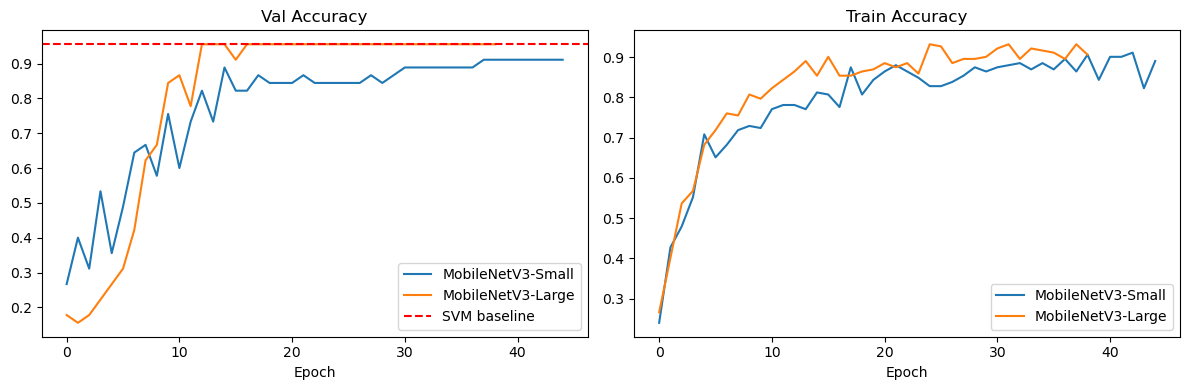

In [7]:
# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, metrics in [('MobileNetV3-Small', metrics_small),
                       ('MobileNetV3-Large', metrics_large)]:
    hist = metrics['history']
    eps = [h['ep'] for h in hist]
    val_accs = [h['vl_acc'] for h in hist]
    axes[0].plot(val_accs, label=name)
    train_accs = [h['tr_acc'] for h in hist]
    axes[1].plot(train_accs, label=name)

axes[0].axhline(0.956, color='red', linestyle='--', label='SVM baseline')
axes[0].set_title('Val Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('Train Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=120)
plt.show()

In [8]:
# Legjobb CNN checkpoint info (06_evaluation.ipynb-nek)
import json
meta = {
    'best_cnn_name': best_cnn_name,
    'best_cnn_ckpt': str(best_cnn_ckpt),
    'best_cnn_val_acc': best_cnn_acc,
    'svm_val_acc': 0.956,
}
(PATHS['output_dir'] / '05b_cnn_finetune').mkdir(parents=True, exist_ok=True)
with open(PATHS['output_dir'] / '05b_cnn_finetune' / 'best_cnn_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'CNN meta mentve.')
print(json.dumps(meta, indent=2))

CNN meta mentve.
{
  "best_cnn_name": "MobileNetV3-Large",
  "best_cnn_ckpt": "/data/Tanulm\u00e1nyok/K\u00e9pfeldolgoz\u00e1s alap algoritmusai/F\u00e9l\u00e9ves feladat/guitar-chord-recognition/checkpoints/best_mobilenet_v3_large_phB.pth",
  "best_cnn_val_acc": 0.9555555555555556,
  "svm_val_acc": 0.956
}
